# Proyecto Final — Predicción del Flujo de Caja
Vyena Teixeira dos Santos

## 1. Formulación del problema

El objetivo del proyecto es predecir los ingresos de caja futuros de una empresa a partir de información histórica de ventas y pagos.

La empresa no trabaja necesariamente con fechas de pago previamente acordadas para todos sus clientes, por lo que existe incertidumbre respecto al momento en que las ventas realizadas se convierten efectivamente en entradas de efectivo.

El problema se formula como una tarea de **regresión supervisada**, donde:

- **Unidad de observación:** período de tiempo agregado.
- **Target:** flujo de caja recibido en un período futuro.
- **Features:** información disponible antes de la fecha de predicción, como ventas históricas, pagos recibidos, saldos pendientes y variables temporales.
- **Objetivo de negocio:** anticipar las entradas de efectivo para mejorar la planificación de liquidez y la toma de decisiones financieras.

### Liberías

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Preparación y exploración de los datos

### Carga de los datos

In [33]:
ruta_ventas = "data/raw/rev_ventas_diarias_2023_jul.2026.xlsx"
ruta_pagos = "data/raw/rev_pagos_recibidos_2023_jul.2026.xlsx"

df_ventas = pd.read_excel(ruta_ventas)
df_pagos = pd.read_excel(ruta_pagos)

print("Ventas:", df_ventas.shape)
print("Pagos:", df_pagos.shape)

print("\nColumnas ventas:")
print(df_ventas.columns.tolist())

print("\nColumnas pagos:")
print(df_pagos.columns.tolist())

Ventas: (258160, 13)
Pagos: (145512, 13)

Columnas ventas:
['Fecha\nVenta', 'Fecha\nTour', 'Editar', 'ID', 'Estado', 'Vendedor', 'Nombre', 'Telefono', 'Tour', 'PAX\nAdulto', 'PAX\nNiño', 'Monto Total', 'VF']

Columnas pagos:
['ID', 'Unnamed: 1', 'Data', 'Voucher', 'Autor', 'Cliente', 'Estado', 'Monto', 'Forma de Pago', 'Obs', 'Fecha', 'Unnamed: 11', 'Unnamed: 12']


### Revisión inicial

In [34]:
display(df_ventas.head())
display(df_pagos.head())

print("\nTipos de datos - ventas:")
print(df_ventas.dtypes)

print("\nTipos de datos - pagos:")
print(df_pagos.dtypes)

print("\nEstados ventas:")
print(df_ventas["Estado"].value_counts(dropna=False))

print("\nEstados pagos:")
print(df_pagos["Estado"].value_counts(dropna=False))

,Fecha\nVenta,Fecha\nTour,Editar,ID,Estado,Vendedor,Nombre,Telefono,Tour,PAX\nAdulto,PAX\nNiño,Monto Total,VF
0,2023-01-01,2023-01-03 00:00:00,NaN,WLC-62207,Reservado,VD Geovanna Casale,Eduardo Dalbem Teles,5.566000e+12,Valparaiso E Vina Del Mar,2,0,60000,NaN
1,2023-01-01,2023-01-04 00:00:00,NaN,WLC-62208,Reservado,VD Geovanna Casale,Eduardo Dalbem Teles,5.566000e+12,Concha Y Toro Marques - Tarde,2,0,100000,NaN
2,2023-01-01,2023-01-02 00:00:00,NaN,WLC-62203,Confirmado,VD Geovanna Casale,Viviane Silva De Lima,5.535991e+12,Valle De La Luna,2,0,70000,NaN
3,2023-01-01,2023-01-05 00:00:00,NaN,WLC-62204,Confirmado,VD Geovanna Casale,Viviane Silva De Lima,5.535991e+12,Piedras Rojas E Lagunas Altiplanicas,2,0,130000,NaN
4,2023-01-01,2023-01-04 00:00:00,NaN,WLC-62205,Reservado,VD Geovanna Casale,Viviane Silva De Lima,5.535991e+12,Geysers El Tatio,2,0,86000,NaN


,ID,Unnamed: 1,Data,Voucher,Autor,Cliente,Estado,Monto,Forma de Pago,Obs,Fecha,Unnamed: 11,Unnamed: 12
0,PAG-25434,NaN,2026-01-01 00:00:00,VF-19621,logingeovanna,Eduardo Dalbem Teles,Pendiente,130000,Transferencia NUBANK,NaN,2023-01-01,01-01,2023-01-01
1,PAG-25433,NaN,2026-01-01 00:00:00,VF-19620,logingeovanna,Viviane Silva De Lima,Pendiente,271700,Transferencia NUBANK,NaN,2023-01-01,01-01,2023-01-01
2,PAG-25426,NaN,2026-01-01 00:00:00,VF-19612,loginmirella,Jorge Antônio Fernandes Da Silva,Pendiente,271000,Transferencia,155,2023-01-01,01-01,2023-01-01
3,PAG-24410,NaN,2026-01-01 00:00:00,VF-18690,loginsulamita,Beatriz Lins Gorgonio Bartolomei,Confirmado,280000,Wise,pagamento Uyuni,2023-01-01,01-01,2023-01-01
4,PAG-25401,NaN,2026-01-01 00:00:00,VF-19383,logmichelemattoso,Reginaldo Vieira,Recaudado,0,Transferencia,NaN,2023-01-01,01-01,2023-01-01



Tipos de datos - ventas:
Fecha\nVenta    datetime64[ns]
Fecha\nTour             object
Editar                 float64
ID                      object
Estado                  object
Vendedor                object
Nombre                  object
Telefono               float64
Tour                    object
PAX\nAdulto              int64
PAX\nNiño                int64
Monto Total             object
VF                     float64
dtype: object

Tipos de datos - pagos:
ID                       object
Unnamed: 1              float64
Data                     object
Voucher                  object
Autor                    object
Cliente                  object
Estado                   object
Monto                     int64
Forma de Pago            object
Obs                      object
Fecha            datetime64[ns]
Unnamed: 11              object
Unnamed: 12      datetime64[ns]
dtype: object

Estados ventas:
Estado
Reservado     115105
Confirmado    103181
Cancelado      39038
No Show        

### Preparación inicial

In [35]:
# Limpieza de nombres de columnas
df_ventas.columns = df_ventas.columns.str.replace("\n", " ", regex=False).str.strip()
df_pagos.columns = df_pagos.columns.str.strip()

print("Columnas ventas:")
print(df_ventas.columns.tolist())

print("\nColumnas pagos:")
print(df_pagos.columns.tolist())

Columnas ventas:
['Fecha Venta', 'Fecha Tour', 'Editar', 'ID', 'Estado', 'Vendedor', 'Nombre', 'Telefono', 'Tour', 'PAX Adulto', 'PAX Niño', 'Monto Total', 'VF']

Columnas pagos:
['ID', 'Unnamed: 1', 'Data', 'Voucher', 'Autor', 'Cliente', 'Estado', 'Monto', 'Forma de Pago', 'Obs', 'Fecha', 'Unnamed: 11', 'Unnamed: 12']


### Revisión de variables principales

In [36]:
print("Estados de ventas:")
print(df_ventas["Estado"].value_counts(dropna=False).to_string())

print("\nEstados de pagos:")
print(df_pagos["Estado"].value_counts(dropna=False).to_string())

print("\nTipo de Fecha en pagos:")
print(df_pagos["Fecha"].dtype)

print("\nEjemplos de Monto Total:")
print(df_ventas["Monto Total"].head(10).tolist())

print("\nEjemplos de Monto:")
print(df_pagos["Monto"].head(10).tolist())

Estados de ventas:
Estado
Reservado     115105
Confirmado    103181
Cancelado      39038
No Show          708
Realizado        128

Estados de pagos:
Estado
Confirmado    103918
Pendiente      19496
Recaudado      11662
Pagado          9854
Invalido         582

Tipo de Fecha en pagos:
datetime64[ns]

Ejemplos de Monto Total:
[60000, 100000, 70000, 130000, 86000, -14300, 84000, 195000, 90000, 64000]

Ejemplos de Monto:
[130000, 271700, 271000, 280000, 0, 0, 196000, 100000, 168800, 44000]


### Revisión de pagos válidos

In [37]:
# Se excluyen únicamente los registros inválidos
df_pagos_validos = df_pagos[df_pagos["Estado"] != "Invalido"].copy()

# Identificación del tipo de movimiento según el ID
df_pagos_validos["Prefijo"] = (
    df_pagos_validos["ID"]
    .astype(str)
    .str[:3]
    .str.upper()
)

print(df_pagos_validos["Prefijo"].value_counts())

print("\nResumen por tipo de movimiento:")
print(
    df_pagos_validos.groupby("Prefijo")["Monto"]
    .agg(["count", "sum", "min", "max"])
)

Prefijo
PAG    134477
REE     10453
Name: count, dtype: int64

Resumen por tipo de movimiento:
          count          sum      min      max
Prefijo                                       
PAG      134477  20204933199        0  7127206
REE       10453  -1049280244 -1555004        0


## 2. Construcción del flujo de caja diario

### Flujo de caja neto por día

In [38]:
flujo_diario = (
    df_pagos_validos
    .groupby("Fecha", as_index=False)["Monto"]
    .sum()
    .rename(columns={"Monto": "Flujo_Caja"})
)

display(flujo_diario.head())

print("Período:", flujo_diario["Fecha"].min(), "a", flujo_diario["Fecha"].max())
print("Días con movimientos:", flujo_diario["Fecha"].nunique())

,Fecha,Flujo_Caja
0,2023-01-01,3568020
1,2023-01-02,15283016
2,2023-01-03,9529004
3,2023-01-04,11291093
4,2023-01-05,10427719


Período: 2023-01-01 00:00:00 a 2026-07-31 00:00:00
Días con movimientos: 1308


### Verificación de continuidad temporal

In [41]:
fechas_completas = pd.date_range(
    start=flujo_diario["Fecha"].min(),
    end=flujo_diario["Fecha"].max(),
    freq="D"
)

print("Días esperados:", len(fechas_completas))
print("Días observados:", flujo_diario["Fecha"].nunique())
print("Días faltantes:", len(fechas_completas) - flujo_diario["Fecha"].nunique())

Días esperados: 1308
Días observados: 1308
Días faltantes: 0


### Evolución del flujo de caja

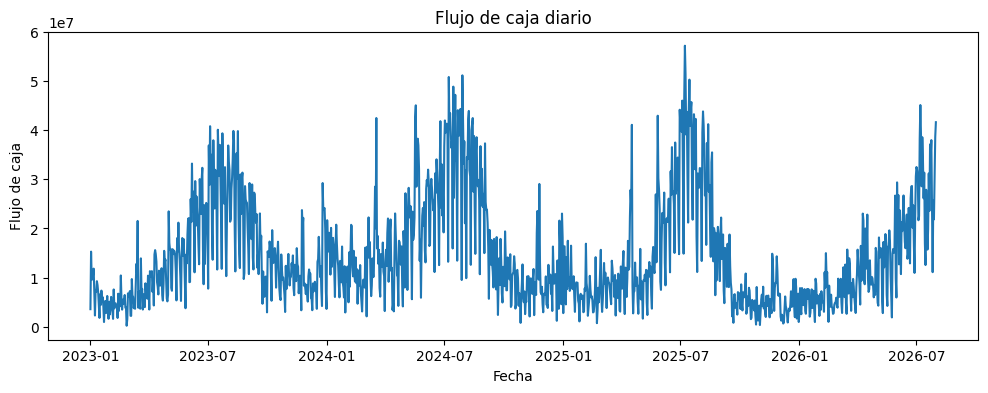

In [42]:
plt.figure(figsize=(12, 4))
plt.plot(flujo_diario["Fecha"], flujo_diario["Flujo_Caja"])

plt.title("Flujo de caja diario")
plt.xlabel("Fecha")
plt.ylabel("Flujo de caja")
plt.show()